<a href="https://colab.research.google.com/github/hjchoi00/AI_lab/blob/main/tacotron2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [35]:
try:
    import torch
    print("✓ PyTorch is successfully imported!")
    print(f"PyTorch version: {torch.__version__}")

    # Check if CUDA is available
    if torch.cuda.is_available():
        device = torch.device('cuda')
        print(f"✓ CUDA is available! Device count: {torch.cuda.device_count()}")
        print(f"Current CUDA device: {torch.cuda.get_device_name(0)}")
    else:
        print("CUDA is not available. Using CPU.")

    # Create a simple tensor to test basic functionality
    test_tensor = torch.tensor([1, 2, 3, 4, 5], device=device)
    print(f"✓ Test tensor created: {test_tensor}")
    print(f"Tensor shape: {test_tensor.shape}")
    print(f"Tensor device: {test_tensor.device}")  # cuda:0 나옴

    squared_tensor = test_tensor ** 2
    print(f"✓ Basic operation test (squaring): {squared_tensor}")

    print("\n🎉 PyTorch is working correctly!")

except ImportError as e:
    print("❌ PyTorch is not installed or not available")
    print(f"Error details: {e}")
    print("Please install PyTorch using: pip install torch")

except Exception as e:
    print(f"❌ An error occurred while testing PyTorch: {e}")

✓ PyTorch is successfully imported!
PyTorch version: 2.8.0+cu126
✓ CUDA is available! Device count: 1
Current CUDA device: Tesla T4
✓ Test tensor created: tensor([1, 2, 3, 4, 5], device='cuda:0')
Tensor shape: torch.Size([5])
Tensor device: cuda:0
✓ Basic operation test (squaring): tensor([ 1,  4,  9, 16, 25], device='cuda:0')

🎉 PyTorch is working correctly!


In [36]:
%%bash
pip3 install deep_phonemizer

In [37]:
import torch
import torchaudio

torch.random.manual_seed(0)
device = "cuda" if torch.cuda.is_available() else "cpu"

print(torch.__version__)
print(torchaudio.__version__)
print(device)

2.8.0+cu126
2.8.0+cu126
cuda


In [38]:
import IPython
import matplotlib.pyplot as plt

## Text Processing

### Character-based encoding

In [39]:
symbols = "_-!'(),.:;? abcdefghijklmnopqrstuvwxyz"
look_up = {s: i for i, s in enumerate(symbols)}
symbols = set(symbols)


def text_to_sequence(text):
    text = text.lower()
    return [look_up[s] for s in text if s in symbols]


text = "Hi, my name is Hyunjoon Choi. I am from Cheongju, Korea."
print(text_to_sequence(text))

[19, 20, 6, 11, 24, 36, 11, 25, 12, 24, 16, 11, 20, 30, 11, 19, 36, 32, 25, 21, 26, 26, 25, 11, 14, 19, 26, 20, 7, 11, 20, 11, 12, 24, 11, 17, 29, 26, 24, 11, 14, 19, 16, 26, 25, 18, 21, 32, 6, 11, 22, 26, 29, 16, 12, 7]


In [40]:
processor = torchaudio.pipelines.TACOTRON2_WAVERNN_CHAR_LJSPEECH.get_text_processor()

text = "Hi, my name is Hyunjoon Choi. I am from Cheongju, Korea."
processed, lengths = processor(text)

print(processed)
print(lengths)


tensor([[19, 20,  6, 11, 24, 36, 11, 25, 12, 24, 16, 11, 20, 30, 11, 19, 36, 32,
         25, 21, 26, 26, 25, 11, 14, 19, 26, 20,  7, 11, 20, 11, 12, 24, 11, 17,
         29, 26, 24, 11, 14, 19, 16, 26, 25, 18, 21, 32,  6, 11, 22, 26, 29, 16,
         12,  7]])
tensor([56], dtype=torch.int32)


In [41]:
print([processor.tokens[i] for i in processed[0, : lengths[0]]])

['h', 'i', ',', ' ', 'm', 'y', ' ', 'n', 'a', 'm', 'e', ' ', 'i', 's', ' ', 'h', 'y', 'u', 'n', 'j', 'o', 'o', 'n', ' ', 'c', 'h', 'o', 'i', '.', ' ', 'i', ' ', 'a', 'm', ' ', 'f', 'r', 'o', 'm', ' ', 'c', 'h', 'e', 'o', 'n', 'g', 'j', 'u', ',', ' ', 'k', 'o', 'r', 'e', 'a', '.']


### Phoneme-based encoding

In [42]:
bundle = torchaudio.pipelines.TACOTRON2_WAVERNN_PHONE_LJSPEECH

processor = bundle.get_text_processor()

text = "Hi, my name is Hyunjoon Choi. I am from Cheongju, Korea."
with torch.inference_mode():
    processed, lengths = processor(text)

print(processed)
print(lengths)

tensor([[54, 32,  6, 11, 66, 32, 11, 67, 48, 66, 11, 55, 94, 11, 54, 93, 20, 67,
         63, 87, 67, 11, 37, 73,  7, 11, 32, 11, 16, 66, 11, 52, 78, 20, 66, 11,
         37, 59, 24, 68, 63, 87,  6, 11, 64, 24, 78, 59, 20,  7]])
tensor([50], dtype=torch.int32)


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(


In [43]:
print([processor.tokens[i] for i in processed[0, : lengths[0]]])

['HH', 'AY', ',', ' ', 'M', 'AY', ' ', 'N', 'EY', 'M', ' ', 'IH', 'Z', ' ', 'HH', 'Y', 'AH', 'N', 'JH', 'UW', 'N', ' ', 'CH', 'OY', '.', ' ', 'AY', ' ', 'AE', 'M', ' ', 'F', 'R', 'AH', 'M', ' ', 'CH', 'IY', 'AO', 'NG', 'JH', 'UW', ',', ' ', 'K', 'AO', 'R', 'IY', 'AH', '.']


## Spectrogram Generation

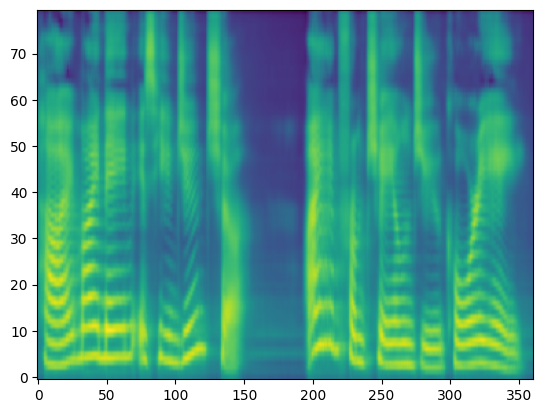

In [44]:
bundle = torchaudio.pipelines.TACOTRON2_WAVERNN_PHONE_LJSPEECH
processor = bundle.get_text_processor()
tacotron2 = bundle.get_tacotron2().to(device)

text = "Hi, my name is Hyunjoon Choi. I am from Cheongju, Korea."

with torch.inference_mode():
    processed, lengths = processor(text)
    processed = processed.to(device)
    lengths = lengths.to(device)
    spec, _, _ = tacotron2.infer(processed, lengths)


_ = plt.imshow(spec[0].cpu().detach(), origin="lower", aspect="auto")

torch.Size([80, 364])
torch.Size([80, 362])
torch.Size([80, 396])


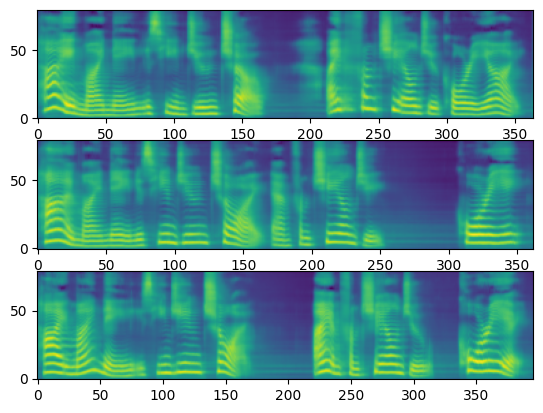

In [45]:
def plot():
    fig, ax = plt.subplots(3, 1)
    for i in range(3):
        with torch.inference_mode():
            spec, spec_lengths, _ = tacotron2.infer(processed, lengths)
        print(spec[0].shape)
        ax[i].imshow(spec[0].cpu().detach(), origin="lower", aspect="auto")


plot()

## Waveform Generation

### WaveRNN Vocoder

In [46]:
bundle = torchaudio.pipelines.TACOTRON2_WAVERNN_PHONE_LJSPEECH

processor = bundle.get_text_processor()
tacotron2 = bundle.get_tacotron2().to(device)
vocoder = bundle.get_vocoder().to(device)

text = "Hi, my name is Hyunjoon Choi. I am from Cheongju, Korea."

with torch.inference_mode():
    processed, lengths = processor(text)
    processed = processed.to(device)
    lengths = lengths.to(device)
    spec, spec_lengths, _ = tacotron2.infer(processed, lengths)
    waveforms, lengths = vocoder(spec, spec_lengths)

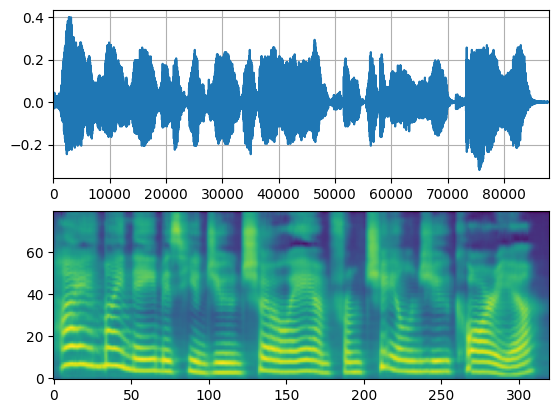

In [47]:
def plot(waveforms, spec, sample_rate):
    waveforms = waveforms.cpu().detach()

    fig, [ax1, ax2] = plt.subplots(2, 1)
    ax1.plot(waveforms[0])
    ax1.set_xlim(0, waveforms.size(-1))
    ax1.grid(True)
    ax2.imshow(spec[0].cpu().detach(), origin="lower", aspect="auto")
    return IPython.display.Audio(waveforms[0:1], rate=sample_rate)


plot(waveforms, spec, vocoder.sample_rate)

### Griffin-Lim Vocoder

In [48]:
bundle = torchaudio.pipelines.TACOTRON2_GRIFFINLIM_PHONE_LJSPEECH

processor = bundle.get_text_processor()
tacotron2 = bundle.get_tacotron2().to(device)
vocoder = bundle.get_vocoder().to(device)

with torch.inference_mode():
    processed, lengths = processor(text)
    processed = processed.to(device)
    lengths = lengths.to(device)
    spec, spec_lengths, _ = tacotron2.infer(processed, lengths)
waveforms, lengths = vocoder(spec, spec_lengths)

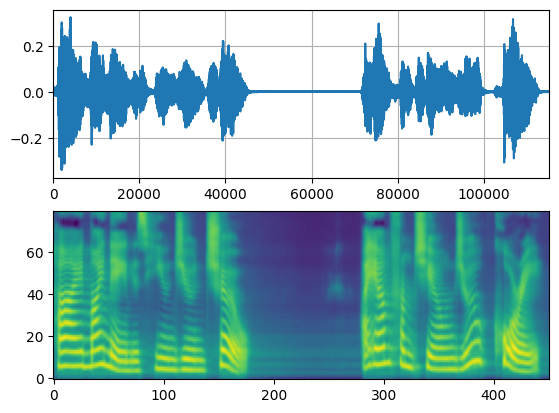

In [49]:
plot(waveforms, spec, vocoder.sample_rate)

### Waveglow Vocoder

In [50]:
# Workaround to load model mapped on GPU
# https://stackoverflow.com/a/61840832
waveglow = torch.hub.load(
    "NVIDIA/DeepLearningExamples:torchhub",
    "nvidia_waveglow",
    model_math="fp32",
    pretrained=False,
)
checkpoint = torch.hub.load_state_dict_from_url(
    "https://api.ngc.nvidia.com/v2/models/nvidia/waveglowpyt_fp32/versions/1/files/nvidia_waveglowpyt_fp32_20190306.pth",  # noqa: E501
    progress=False,
    map_location=device,
)
state_dict = {key.replace("module.", ""): value for key, value in checkpoint["state_dict"].items()}

waveglow.load_state_dict(state_dict)
waveglow = waveglow.remove_weightnorm(waveglow)
waveglow = waveglow.to(device)
waveglow.eval()

with torch.no_grad():
    waveforms = waveglow.infer(spec)

Using cache found in /root/.cache/torch/hub/NVIDIA_DeepLearningExamples_torchhub
/usr/local/lib/python3.12/dist-packages/torch/nn/utils/weight_norm.py:144: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)


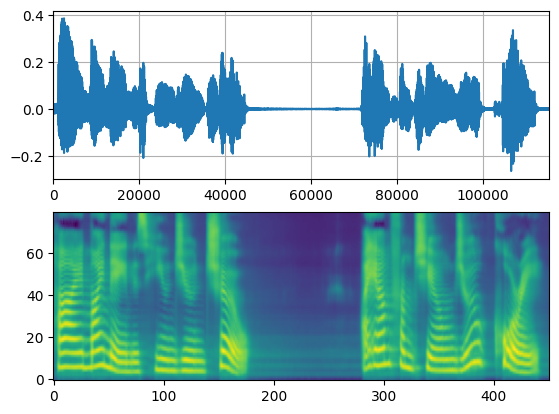

In [51]:
plot(waveforms, spec, 22050)